# Embedding Space Analysis for Gait Recognition

This notebook analyzes embedding space differences between different input types (views, sequences, subjects) using trained models from `gait/models/`.

## Objectives:
1. Load trained model weights (Autoencoder and VAE)
2. Extract embeddings from CASIA-B images
3. Compare embeddings across different:
   - **Views** (different camera angles: 000, 018, 036, etc.)
   - **Sequences** (nm-01, nm-02, bg-01, cl-01, etc.)
   - **Subjects** (001, 002, 003, etc.)
4. Visualize embedding space using dimensionality reduction (t-SNE, PCA)
5. Display images alongside their embeddings


In [2]:
# Setup and imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

# Deep learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# Computer vision
from PIL import Image
import cv2

# Dimensionality reduction and visualization
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

# Add paths for model imports
sys.path.append(str(Path('gait/models/autoencoder').resolve()))
sys.path.append(str(Path('gait/models/vae').resolve()))
sys.path.append(str(Path('gait/preprocessing').resolve()))

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


Using device: cuda
PyTorch version: 2.5.1+cu121


## 1. Load Trained Models


In [3]:
# Import model creation functions
from gait.models.autoencoder.model import create_autoencoder
from gait.models.vae.model import create_vae

# Model paths
AUTOENCODER_CHECKPOINT = Path('gait/models/best_model.pth')
VAE_CHECKPOINT = Path('gait/models/best_model_vae.pth')

# Load Autoencoder
print("Loading Autoencoder...")
autoencoder = create_autoencoder(embedding_dim=128)
if AUTOENCODER_CHECKPOINT.exists():
    checkpoint = torch.load(AUTOENCODER_CHECKPOINT, map_location=device)
    autoencoder.load_state_dict(checkpoint['model_state_dict'])
    autoencoder = autoencoder.to(device)
    autoencoder.eval()
    print(f"✅ Autoencoder loaded (Epoch: {checkpoint.get('epoch', 'N/A')})")
else:
    print(f"⚠️  Autoencoder checkpoint not found at {AUTOENCODER_CHECKPOINT}")

# Load VAE
print("\nLoading VAE...")
vae = create_vae(latent_dim=128)
if VAE_CHECKPOINT.exists():
    checkpoint = torch.load(VAE_CHECKPOINT, map_location=device)
    vae.load_state_dict(checkpoint['model_state_dict'])
    vae = vae.to(device)
    vae.eval()
    print(f"✅ VAE loaded (Epoch: {checkpoint.get('epoch', 'N/A')})")
else:
    print(f"⚠️  VAE checkpoint not found at {VAE_CHECKPOINT}")

# Choose which model to use (default: autoencoder if available)
MODEL_TO_USE = 'autoencoder' if AUTOENCODER_CHECKPOINT.exists() else 'vae'
print(f"\n📌 Using model: {MODEL_TO_USE}")


Loading Autoencoder...
✅ Autoencoder loaded (Epoch: 44)

Loading VAE...
✅ VAE loaded (Epoch: 49)

📌 Using model: autoencoder


In [ ]:
# Import contrastive model
from gait.models.vae.contrastive_model import create_contrastive_vae

# Contrastive VAE checkpoint path
CONTRASTIVE_CHECKPOINT = Path('gait/models/vae/checkpoints_contrastive/best_model.pth')

# Load Contrastive VAE
print("\nLoading Contrastive VAE...")
contrastive_vae = create_contrastive_vae(latent_dim=128, projection_dim=128)
if CONTRASTIVE_CHECKPOINT.exists():
    checkpoint = torch.load(CONTRASTIVE_CHECKPOINT, map_location=device)
    contrastive_vae.load_state_dict(checkpoint['model_state_dict'])
    contrastive_vae = contrastive_vae.to(device)
    contrastive_vae.eval()
    print(f"✅ Contrastive VAE loaded (Epoch: {checkpoint.get('epoch', 'N/A')})")
    print(f"   Val Total Loss: {checkpoint.get('val_total_loss', 'N/A'):.6f}")
    print(f"   Val Contrastive Loss: {checkpoint.get('val_contrastive_loss', 'N/A'):.6f}")
else:
    print(f"⚠️  Contrastive VAE checkpoint not found at {CONTRASTIVE_CHECKPOINT}")

# Choose which model to use
MODEL_TO_USE = 'contrastive' if CONTRASTIVE_CHECKPOINT.exists() else ('autoencoder' if AUTOENCODER_CHECKPOINT.exists() else 'vae')
print(f"\n📌 Using model: {MODEL_TO_USE}")


Loading Contrastive VAE...
✅ Contrastive VAE loaded (Epoch: 49)
   Val Total Loss: 27.147800
   Val Contrastive Loss: 5.230775

📌 Using model: contrastive


## 2. Image Loading and Preprocessing


In [5]:
# Collect sample images from different categories
def collect_sample_images(images_root, max_samples_per_category=10):
    """
    Collect images from different categories for analysis.
    Returns dict with metadata and paths.
    """
    samples = {
        'paths': [],
        'subjects': [],
        'sequences': [],
        'views': [],
        'metadata': []
    }
    
    images_root = Path(images_root)
    if not images_root.exists():
        print(f"⚠️  Images directory not found: {images_root}")
        return samples
    
    # Priority sequence types: nm (normal), bg (bag), cl (coat)
    priority_sequences = ['nm', 'bg', 'cl']
    
    # Sample from different subjects, sequences, and views
    subject_dirs = sorted([d for d in images_root.iterdir() if d.is_dir()])[:10]  # First 10 subjects
    
    for subject_dir in subject_dirs:
        subject_id = subject_dir.name
        
        # Get all sequences and prioritize nm, bg, cl
        all_sequences = sorted([d for d in subject_dir.iterdir() if d.is_dir()])
        
        # Group sequences by type
        sequences_by_type = {}
        for seq_dir in all_sequences:
            seq_type = seq_dir.name.split('-')[0]  # Extract nm, bg, or cl
            if seq_type not in sequences_by_type:
                sequences_by_type[seq_type] = []
            sequences_by_type[seq_type].append(seq_dir)
        
        # Collect from priority sequences (nm, bg, cl)
        selected_sequences = []
        for seq_type in priority_sequences:
            if seq_type in sequences_by_type:
                # Take first sequence of each type (e.g., nm-01, bg-01, cl-01)
                selected_sequences.extend(sequences_by_type[seq_type][:1])
        
        # If we don't have all three types, add more sequences
        if len(selected_sequences) < 3:
            for seq_dir in all_sequences:
                if seq_dir not in selected_sequences:
                    selected_sequences.append(seq_dir)
                    if len(selected_sequences) >= 3:
                        break
        
        for seq_dir in selected_sequences:
            sequence_id = seq_dir.name
            view_dirs = sorted([d for d in seq_dir.iterdir() if d.is_dir()])[:3]  # First 3 views
            
            for view_dir in view_dirs:
                view_id = view_dir.name
                image_files = sorted(list(view_dir.glob('*.png')))[:2]  # First 2 images per view
                
                for img_path in image_files:
                    samples['paths'].append(img_path)
                    samples['subjects'].append(subject_id)
                    samples['sequences'].append(sequence_id)
                    samples['views'].append(view_id)
                    samples['metadata'].append(parse_filename(img_path))
    
    print(f"📸 Collected {len(samples['paths'])} sample images")
    print(f"   Subjects: {len(set(samples['subjects']))}")
    print(f"   Sequences: {len(set(samples['sequences']))}")
    print(f"   Sequence types: {set([s.split('-')[0] for s in samples['sequences']])}")
    print(f"   Views: {len(set(samples['views']))}")
    
    return samples

In [21]:
# Path to CASIA-B images
IMAGES_ROOT = Path('Casia-B-Images/output')

def parse_filename(filename):
    """
    Parse CASIA-B image filename.
    Format: {subject}-{sequence}-{view}-{frame}.png
    Example: 001-nm-01-000-001.png
    """
    parts = filename.stem.split('-')
    if len(parts) >= 4:
        return {
            'subject': parts[0],
            'sequence': f"{parts[1]}-{parts[2]}",  # e.g., "nm-01"
            'view': parts[3],
            'frame': parts[4] if len(parts) > 4 else None
        }
    return None

def load_and_preprocess_image(image_path, target_size=(128, 64)):
    """
    Load and preprocess image for model input.
    Returns tensor of shape (1, 1, 128, 64) normalized to [0, 1]
    """
    img = Image.open(image_path).convert('L')  # Convert to grayscale
    img = img.resize(target_size, Image.LANCZOS)
    img_array = np.array(img, dtype=np.float32) / 255.0  # Normalize to [0, 1]
    
    # Convert to tensor: (1, 1, 128, 64)
    tensor = torch.from_numpy(img_array).unsqueeze(0).unsqueeze(0)
    return tensor

# Collect sample images from different categories
def collect_sample_images(images_root, max_subjects=10, max_samples_per_category=10):
    """
    Collect images from different categories for analysis.
    Prioritizes getting nm (normal), bg (bag), and cl (coat) sequences.
    Returns dict with metadata and paths.
    """
    samples = {
        'paths': [],
        'subjects': [],
        'sequences': [],
        'views': [],
        'metadata': []
    }
    
    images_root = Path(images_root)
    if not images_root.exists():
        print(f"⚠️  Images directory not found: {images_root}")
        return samples
    
    # Priority sequence types: nm (normal), bg (bag), cl (coat)
    priority_sequences = ['nm', 'bg', 'cl']
    
    # Sample from different subjects, sequences, and views
    subject_dirs = sorted([d for d in images_root.iterdir() if d.is_dir()])[:max_subjects]  # First 10 subjects
    
    for subject_dir in subject_dirs:
        subject_id = subject_dir.name
        
        # Get all sequences and group by type
        all_sequences = sorted([d for d in subject_dir.iterdir() if d.is_dir()])
        
        # Group sequences by type (nm, bg, cl)
        sequences_by_type = {}
        for seq_dir in all_sequences:
            seq_type = seq_dir.name.split('-')[0]  # Extract nm, bg, or cl
            if seq_type not in sequences_by_type:
                sequences_by_type[seq_type] = []
            sequences_by_type[seq_type].append(seq_dir)
        
        # Collect from priority sequences (nm, bg, cl) - take first sequence of each type
        selected_sequences = []
        for seq_type in priority_sequences:
            if seq_type in sequences_by_type:
                # Take first sequence of each type (e.g., nm-01, bg-01, cl-01)
                selected_sequences.extend(sequences_by_type[seq_type][:1])
        
        # If we don't have all three types, add more sequences to fill up to 3
        if len(selected_sequences) < 3:
            for seq_dir in all_sequences:
                if seq_dir not in selected_sequences:
                    selected_sequences.append(seq_dir)
                    if len(selected_sequences) >= 3:
                        break
        
        for seq_dir in selected_sequences:
            sequence_id = seq_dir.name
            view_dirs = sorted([d for d in seq_dir.iterdir() if d.is_dir()])[:3]  # First 3 views
            
            for view_dir in view_dirs:
                view_id = view_dir.name
                image_files = sorted(list(view_dir.glob('*.png')))[:2]  # First 2 images per view
                
                for img_path in image_files:
                    samples['paths'].append(img_path)
                    samples['subjects'].append(subject_id)
                    samples['sequences'].append(sequence_id)
                    samples['views'].append(view_id)
                    samples['metadata'].append(parse_filename(img_path))
    
    # Print collected sequence types
    sequence_types = set([seq.split('-')[0] for seq in samples['sequences']])
    
    print(f"📸 Collected {len(samples['paths'])} sample images")
    print(f"   Subjects: {len(set(samples['subjects']))}")
    print(f"   Sequences: {len(set(samples['sequences']))}")
    print(f"   Sequence types: {sorted(sequence_types)}")
    print(f"   Views: {len(set(samples['views']))}")
    
    return samples

# Collect images
samples = collect_sample_images(IMAGES_ROOT, max_subjects=10000, max_samples_per_category=10000)


📸 Collected 2232 sample images
   Subjects: 124
   Sequences: 3
   Sequence types: ['bg', 'cl', 'nm']
   Views: 4


In [54]:
def extract_embeddings(model, image_paths, model_type='autoencoder', batch_size=32, use_projection=False):
    """
    Extract embeddings from images using the trained model.
    
    Args:
        model: Trained model (autoencoder, VAE, or Contrastive VAE)
        image_paths: List of image paths
        model_type: 'autoencoder', 'vae', or 'contrastive'
        batch_size: Batch size for processing
        use_projection: For contrastive model, use projection head (default: False, uses raw embedding)
    
    Returns:
        embeddings: numpy array (N, embedding_dim)
    """
    embeddings_list = []
    
    model.eval()
    with torch.no_grad():
        for i in range(0, len(image_paths), batch_size):
            batch_paths = image_paths[i:i+batch_size]
            batch_tensors = []
            
            # Load and preprocess batch
            for img_path in batch_paths:
                tensor = load_and_preprocess_image(img_path)
                batch_tensors.append(tensor)
            
            # Stack into batch
            batch = torch.cat(batch_tensors, dim=0).to(device)
            
            # Extract embeddings
            if model_type == 'autoencoder':
                embedding = model.encode(batch)
            elif model_type == 'vae':
                mu, _ = model.encode(batch)
                embedding = mu
            elif model_type == 'contrastive':
                if use_projection:
                    # Use projection head embedding
                    projection, _, _ = model.get_projection(batch)
                    embedding = projection
                else:
                    # Use raw VAE embedding (latent mean)
                    embedding = model.get_embedding(batch)
            else:
                raise ValueError(f"Unknown model type: {model_type}")
            
            embeddings_list.append(embedding.cpu().numpy())
    
    embeddings = np.concatenate(embeddings_list, axis=0)
    return embeddings

# Extract embeddings from VAE and Contrastive VAE for comparison
print("Extracting embeddings from VAE and Contrastive VAE...\n")

embeddings_dict = {}
embeddings = None

# Extract VAE embeddings
if VAE_CHECKPOINT.exists():
    embeddings_vae = extract_embeddings(vae, samples['paths'], model_type='vae')
    embeddings_dict['vae'] = embeddings_vae
    print(f"✅ VAE embeddings: {embeddings_vae.shape[0]} x {embeddings_vae.shape[1]} "
          f"(mean={embeddings_vae.mean():.4f}, std={embeddings_vae.std():.4f})")
    embeddings = embeddings_vae  # Use VAE as default for main analysis

# Extract Contrastive VAE embeddings (raw latent mean)
if CONTRASTIVE_CHECKPOINT.exists():
    embeddings_contrastive = extract_embeddings(contrastive_vae, samples['paths'], 
                                                 model_type='contrastive', use_projection=False)
    embeddings_dict['contrastive'] = embeddings_contrastive
    print(f"✅ Contrastive VAE embeddings: {embeddings_contrastive.shape[0]} x {embeddings_contrastive.shape[1]} "
          f"(mean={embeddings_contrastive.mean():.4f}, std={embeddings_contrastive.std():.4f})")

# Fallback to autoencoder if VAE not available
if embeddings is None and AUTOENCODER_CHECKPOINT.exists():
    embeddings_ae = extract_embeddings(autoencoder, samples['paths'], model_type='autoencoder')
    embeddings_dict['autoencoder'] = embeddings_ae
    embeddings = embeddings_ae
    print(f"✅ Autoencoder embeddings: {embeddings_ae.shape[0]} x {embeddings_ae.shape[1]} "
          f"(mean={embeddings_ae.mean():.4f}, std={embeddings_ae.std():.4f})")

if embeddings is None:
    print("⚠️  No trained model available. Using random embeddings for demonstration.")
    embeddings = np.random.randn(len(samples['paths']), 128)

# Determine model name
model_name = 'VAE' if 'vae' in embeddings_dict else ('Autoencoder' if 'autoencoder' in embeddings_dict else 'Random')
print(f"\n📌 Using embeddings from: {model_name} (shape: {embeddings.shape})")
print(f"   Embedding stats: mean={embeddings.mean():.4f}, std={embeddings.std():.4f}")

Extracting embeddings from VAE and Contrastive VAE...

✅ VAE embeddings: 2232 x 128 (mean=0.0150, std=0.2759)
✅ Contrastive VAE embeddings: 2232 x 128 (mean=-0.0304, std=0.3267)

📌 Using embeddings from: VAE (shape: (2232, 128))
   Embedding stats: mean=0.0150, std=0.2759


In [55]:
# Prepare sequence-type metadata for downstream visualizations
sequence_types = [seq.split('-')[0] for seq in samples['sequences']]
sequence_type_labels = {
    'nm': 'Normal Walking',
    'bg': 'Carrying Bag',
    'cl': 'Wearing Coat'
}
sequence_type_colors = {
    'nm': 'green',
    'bg': 'orange',
    'cl': 'purple'
}

unique_sequence_types = sorted(set(sequence_types))
print(f"Sequence types available: {unique_sequence_types}")


Sequence types available: ['bg', 'cl', 'nm']


## 4. Analyze Embedding Differences by Category


In [56]:
def compute_category_statistics(embeddings, labels, category_name):
    """
    Compute statistics for embeddings grouped by category.
    
    Returns:
        dict with mean embeddings, distances, and statistics per category
    """
    unique_labels = sorted(set(labels))
    stats = {
        'categories': unique_labels,
        'mean_embeddings': {},
        'intra_category_distances': {},
        'category_sizes': {}
    }
    
    for label in unique_labels:
        mask = np.array(labels) == label
        category_embeddings = embeddings[mask]
        
        # Mean embedding for this category
        mean_emb = category_embeddings.mean(axis=0)
        stats['mean_embeddings'][label] = mean_emb
        
        # Intra-category distances (distances within same category)
        if len(category_embeddings) > 1:
            distances = euclidean_distances(category_embeddings)
            # Get upper triangle (excluding diagonal)
            triu_indices = np.triu_indices(len(distances), k=1)
            intra_distances = distances[triu_indices]
            stats['intra_category_distances'][label] = intra_distances
        
        stats['category_sizes'][label] = len(category_embeddings)
    
    return stats

# Analyze by different categories
print("Analyzing embedding differences by category...\n")

# By Subject
subject_stats = compute_category_statistics(embeddings, samples['subjects'], 'Subject')
print("📊 Subject Analysis:")
for subj in list(subject_stats['categories'])[:5]:
    size = subject_stats['category_sizes'][subj]
    if subj in subject_stats['intra_category_distances']:
        avg_dist = subject_stats['intra_category_distances'][subj].mean()
        print(f"   Subject {subj}: {size} samples, avg intra-distance: {avg_dist:.4f}")

# By Sequence
sequence_stats = compute_category_statistics(embeddings, samples['sequences'], 'Sequence')
print("\n📊 Sequence Analysis:")
for seq in sequence_stats['categories']:
    size = sequence_stats['category_sizes'][seq]
    if seq in sequence_stats['intra_category_distances']:
        avg_dist = sequence_stats['intra_category_distances'][seq].mean()
        print(f"   {seq}: {size} samples, avg intra-distance: {avg_dist:.4f}")

# By View
view_stats = compute_category_statistics(embeddings, samples['views'], 'View')
print("\n📊 View Analysis:")
for view in sorted(view_stats['categories']):
    size = view_stats['category_sizes'][view]
    if view in view_stats['intra_category_distances']:
        avg_dist = view_stats['intra_category_distances'][view].mean()
        print(f"   View {view}: {size} samples, avg intra-distance: {avg_dist:.4f}")


Analyzing embedding differences by category...

📊 Subject Analysis:
   Subject 001: 18 samples, avg intra-distance: 1.0184
   Subject 002: 18 samples, avg intra-distance: 1.2413
   Subject 003: 18 samples, avg intra-distance: 1.0563
   Subject 004: 18 samples, avg intra-distance: 0.8845
   Subject 005: 18 samples, avg intra-distance: 1.7459

📊 Sequence Analysis:
   bg-01: 744 samples, avg intra-distance: 1.4146
   cl-01: 744 samples, avg intra-distance: 1.3917
   nm-01: 744 samples, avg intra-distance: 1.2695

📊 View Analysis:
   View 000: 738 samples, avg intra-distance: 1.1756
   View 018: 744 samples, avg intra-distance: 1.3857
   View 036: 744 samples, avg intra-distance: 1.5089
   View 054: 6 samples, avg intra-distance: 1.4244


## 5. Visualize Embedding Space with Dimensionality Reduction


In [57]:
# Reduce dimensionality for visualization
# Compute t-SNE for all models in embeddings_dict
print("Reducing dimensionality for visualization...")

embeddings_2d_dict = {}
for model_name, model_embeddings in embeddings_dict.items():
    print(f"\nProcessing {model_name}...")
    # PCA first (faster, preserves global structure)
    pca = PCA(n_components=50)
    embeddings_pca = pca.fit_transform(model_embeddings)
    print(f"  PCA: Explained variance ratio: {pca.explained_variance_ratio_[:10].sum():.4f} (first 10 components)")
    
    # t-SNE for 2D visualization (preserves local structure)
    print(f"  Computing t-SNE for {model_name} (this may take a minute)...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(model_embeddings)-1))
    embeddings_2d = tsne.fit_transform(embeddings_pca[:, :50])  # Use first 50 PCA components
    embeddings_2d_dict[model_name] = embeddings_2d
    print(f"  ✅ t-SNE complete for {model_name}")

# Create DataFrame for easier plotting (use VAE as default, or first available)
default_model = 'vae' if 'vae' in embeddings_2d_dict else list(embeddings_2d_dict.keys())[0]
embeddings_2d = embeddings_2d_dict[default_model]
df = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'subject': samples['subjects'],
    'sequence': samples['sequences'],
    'view': samples['views']
})


Reducing dimensionality for visualization...

Processing vae...
  PCA: Explained variance ratio: 0.8344 (first 10 components)
  Computing t-SNE for vae (this may take a minute)...
  ✅ t-SNE complete for vae

Processing contrastive...
  PCA: Explained variance ratio: 0.8210 (first 10 components)
  Computing t-SNE for contrastive (this may take a minute)...
  ✅ t-SNE complete for contrastive


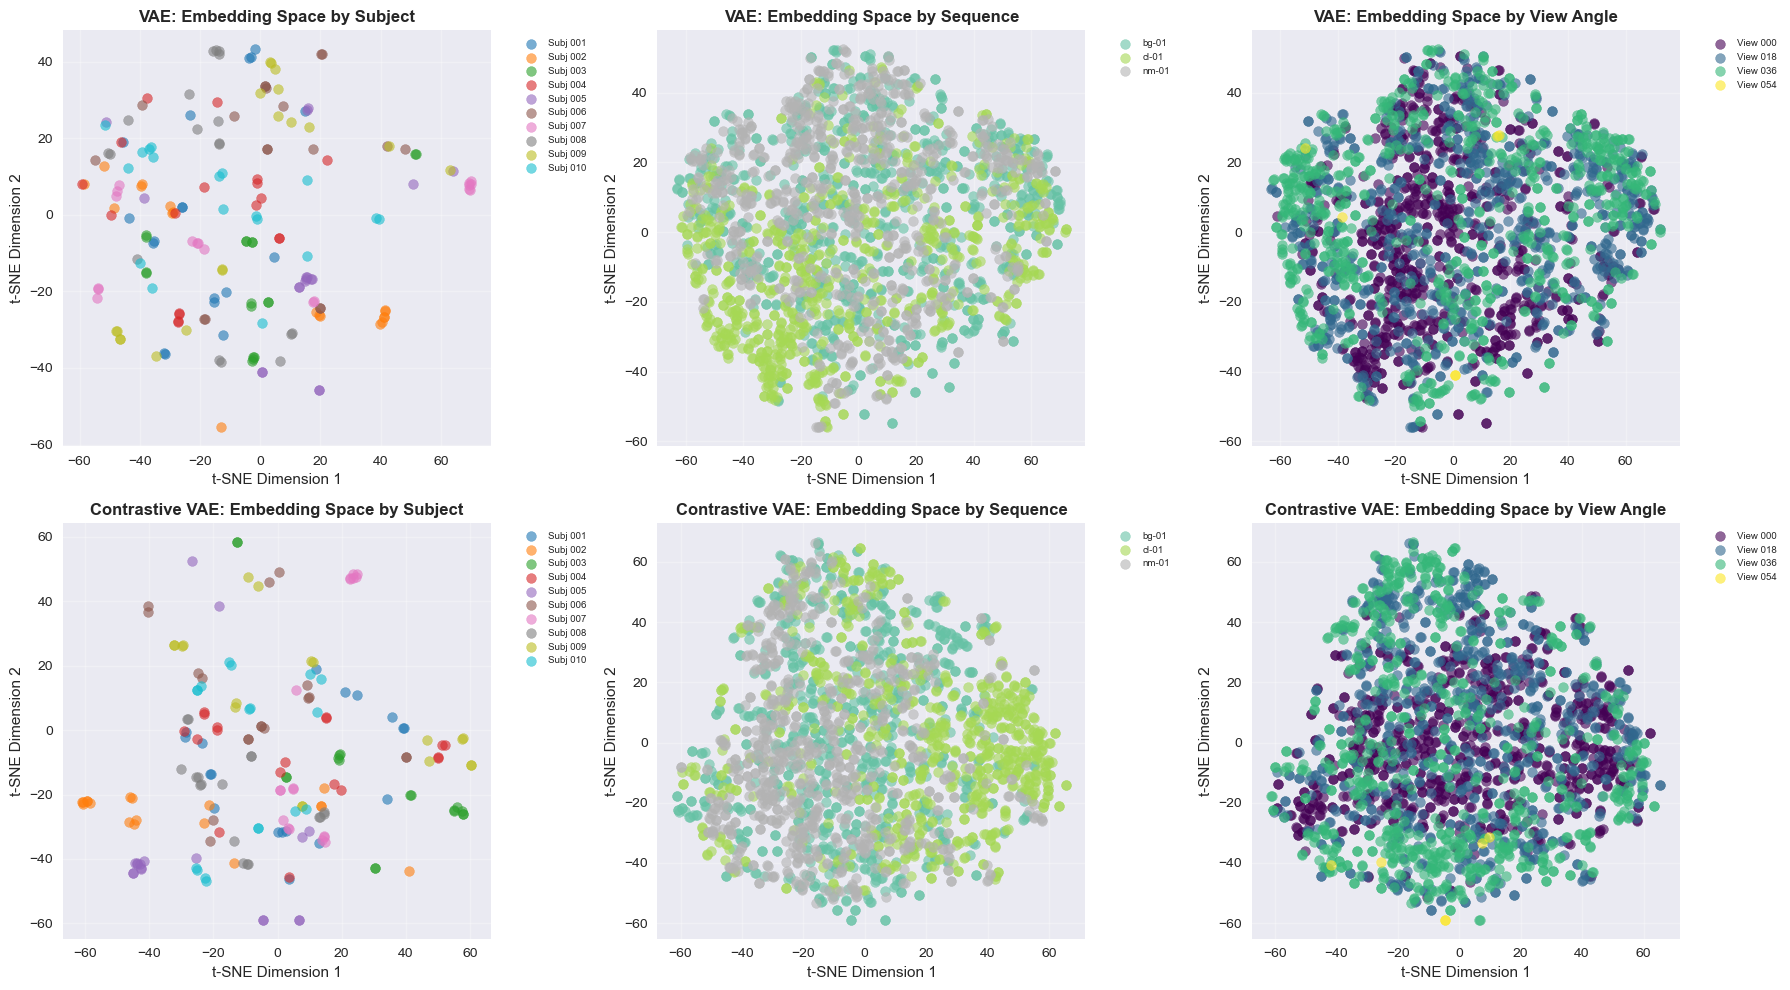

In [ ]:
# Visualize by Subject, Sequence, and View - Compare VAE vs Contrastive VAE
if 'vae' in embeddings_2d_dict and 'contrastive' in embeddings_2d_dict:
    # Side-by-side comparison
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    unique_subjects = sorted(set(samples['subjects']))[:10]  # First 10 subjects
    colors_subject = plt.cm.tab10(np.linspace(0, 1, len(unique_subjects)))
    unique_sequences = sorted(set(samples['sequences']))
    colors_seq = plt.cm.Set2(np.linspace(0, 1, len(unique_sequences)))
    unique_views = sorted(set(samples['views']))
    colors_view = plt.cm.viridis(np.linspace(0, 1, len(unique_views)))
    
    # VAE row
    vae_2d = embeddings_2d_dict['vae']
    df_vae = pd.DataFrame({
        'x': vae_2d[:, 0], 'y': vae_2d[:, 1],
        'subject': samples['subjects'], 'sequence': samples['sequences'], 'view': samples['views']
    })
    
    # Contrastive VAE row
    contrastive_2d = embeddings_2d_dict['contrastive']
    df_contrastive = pd.DataFrame({
        'x': contrastive_2d[:, 0], 'y': contrastive_2d[:, 1],
        'subject': samples['subjects'], 'sequence': samples['sequences'], 'view': samples['views']
    })
    
    # By Subject
    for i, subj in enumerate(unique_subjects):
        mask_vae = df_vae['subject'] == subj
        mask_contrastive = df_contrastive['subject'] == subj
        axes[0, 0].scatter(df_vae[mask_vae]['x'], df_vae[mask_vae]['y'], 
                          c=[colors_subject[i]], label=f'Subj {subj}', alpha=0.6, s=50)
        axes[1, 0].scatter(df_contrastive[mask_contrastive]['x'], df_contrastive[mask_contrastive]['y'], 
                          c=[colors_subject[i]], label=f'Subj {subj}', alpha=0.6, s=50)
    axes[0, 0].set_title('VAE: Embedding Space by Subject', fontsize=12, fontweight='bold')
    axes[1, 0].set_title('Contrastive VAE: Embedding Space by Subject', fontsize=12, fontweight='bold')
    for ax in [axes[0, 0], axes[1, 0]]:
        ax.set_xlabel('t-SNE Dimension 1')
        ax.set_ylabel('t-SNE Dimension 2')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
        ax.grid(True, alpha=0.3)
    
    # By Sequence
    for i, seq in enumerate(unique_sequences):
        mask_vae = df_vae['sequence'] == seq
        mask_contrastive = df_contrastive['sequence'] == seq
        axes[0, 1].scatter(df_vae[mask_vae]['x'], df_vae[mask_vae]['y'], 
                          c=[colors_seq[i]], label=seq, alpha=0.6, s=50)
        axes[1, 1].scatter(df_contrastive[mask_contrastive]['x'], df_contrastive[mask_contrastive]['y'], 
                          c=[colors_seq[i]], label=seq, alpha=0.6, s=50)
    axes[0, 1].set_title('VAE: Embedding Space by Sequence', fontsize=12, fontweight='bold')
    axes[1, 1].set_title('Contrastive VAE: Embedding Space by Sequence', fontsize=12, fontweight='bold')
    for ax in [axes[0, 1], axes[1, 1]]:
        ax.set_xlabel('t-SNE Dimension 1')
        ax.set_ylabel('t-SNE Dimension 2')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
        ax.grid(True, alpha=0.3)
    
    # By View
    for i, view in enumerate(unique_views):
        mask_vae = df_vae['view'] == view
        mask_contrastive = df_contrastive['view'] == view
        axes[0, 2].scatter(df_vae[mask_vae]['x'], df_vae[mask_vae]['y'], 
                          c=[colors_view[i]], label=f'View {view}', alpha=0.6, s=50)
        axes[1, 2].scatter(df_contrastive[mask_contrastive]['x'], df_contrastive[mask_contrastive]['y'], 
                          c=[colors_view[i]], label=f'View {view}', alpha=0.6, s=50)
    axes[0, 2].set_title('VAE: Embedding Space by View Angle', fontsize=12, fontweight='bold')
    axes[1, 2].set_title('Contrastive VAE: Embedding Space by View Angle', fontsize=12, fontweight='bold')
    for ax in [axes[0, 2], axes[1, 2]]:
        ax.set_xlabel('t-SNE Dimension 1')
        ax.set_ylabel('t-SNE Dimension 2')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    # Fallback to single model
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    unique_subjects = sorted(set(samples['subjects']))[:10]
    colors_subject = plt.cm.tab10(np.linspace(0, 1, len(unique_subjects)))
    for i, subj in enumerate(unique_subjects):
        mask = df['subject'] == subj
        axes[0].scatter(df[mask]['x'], df[mask]['y'], 
                       c=[colors_subject[i]], label=f'Subj {subj}', 
                       alpha=0.6, s=50)
    axes[0].set_title('Embedding Space by Subject', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('t-SNE Dimension 1')
    axes[0].set_ylabel('t-SNE Dimension 2')
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[0].grid(True, alpha=0.3)
    
    unique_sequences = sorted(set(samples['sequences']))
    colors_seq = plt.cm.Set2(np.linspace(0, 1, len(unique_sequences)))
    for i, seq in enumerate(unique_sequences):
        mask = df['sequence'] == seq
        axes[1].scatter(df[mask]['x'], df[mask]['y'], 
                       c=[colors_seq[i]], label=seq, 
                       alpha=0.6, s=50)
    axes[1].set_title('Embedding Space by Sequence', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('t-SNE Dimension 1')
    axes[1].set_ylabel('t-SNE Dimension 2')
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[1].grid(True, alpha=0.3)
    
    unique_views = sorted(set(samples['views']))
    colors_view = plt.cm.viridis(np.linspace(0, 1, len(unique_views)))
    for i, view in enumerate(unique_views):
        mask = df['view'] == view
        axes[2].scatter(df[mask]['x'], df[mask]['y'], 
                       c=[colors_view[i]], label=f'View {view}', 
                       alpha=0.6, s=50)
    axes[2].set_title('Embedding Space by View Angle', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('t-SNE Dimension 1')
    axes[2].set_ylabel('t-SNE Dimension 2')
    axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


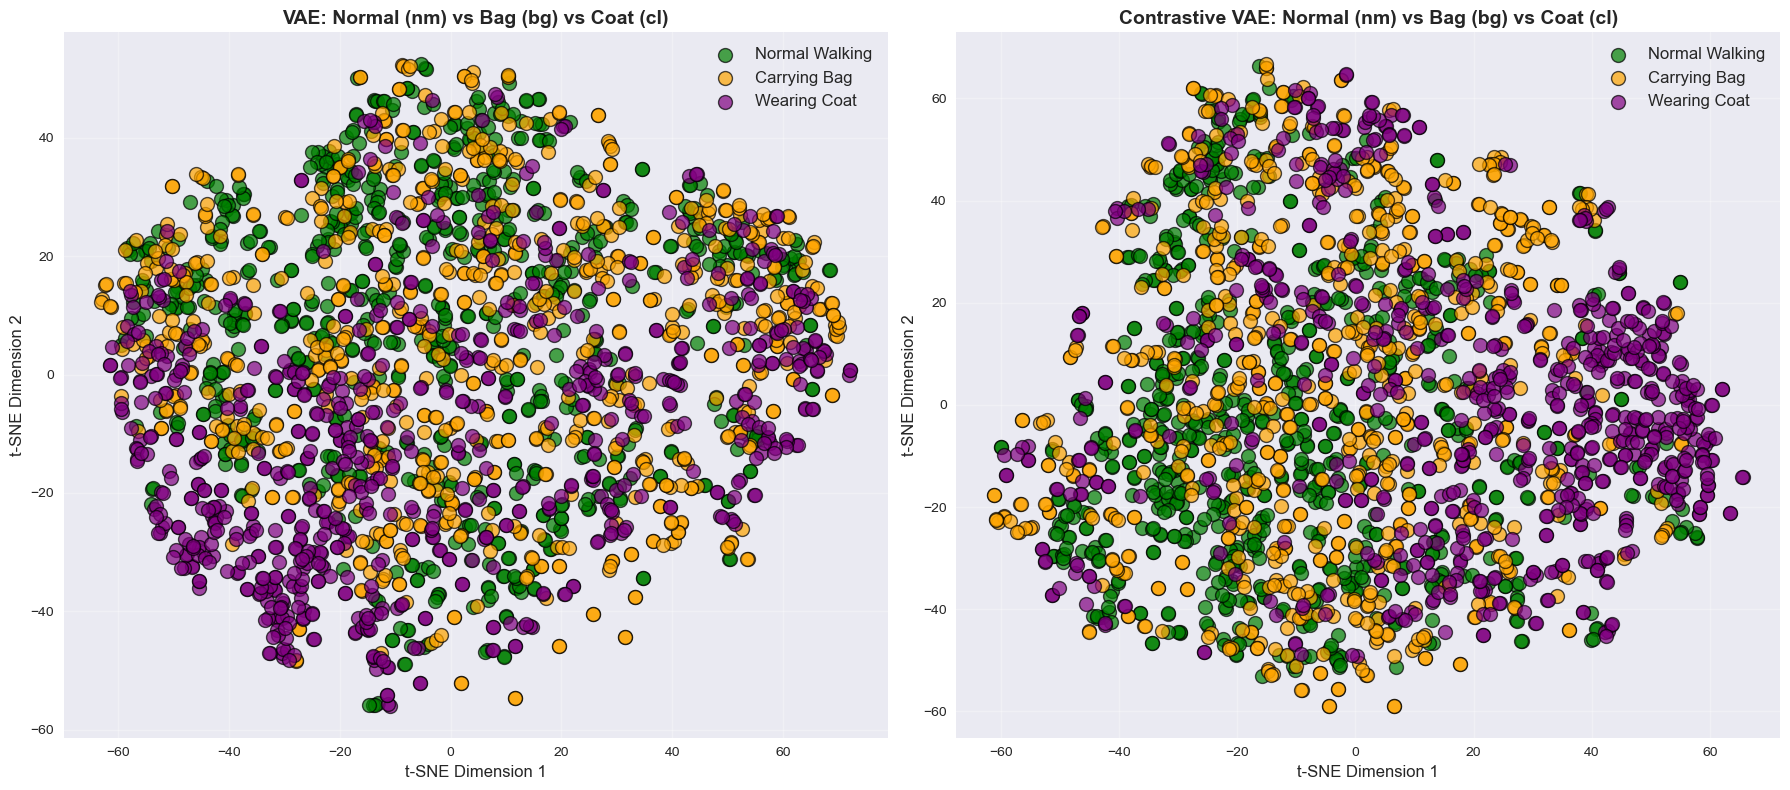


📊 Sequence Type Analysis (nm vs bg vs cl):

VAE:
   Normal Walking (nm):
      Samples: 744
      Mean embedding norm: 3.0279
      Embedding std: 0.0717
   Carrying Bag (bg):
      Samples: 744
      Mean embedding norm: 2.9938
      Embedding std: 0.0791
   Wearing Coat (cl):
      Samples: 744
      Mean embedding norm: 2.8417
      Embedding std: 0.0793

   Distances Between Sequence Types (VAE):
      Carrying Bag ↔ Normal Walking: 1.3520 ± 0.4543
      Carrying Bag ↔ Wearing Coat: 1.4408 ± 0.4910
      Wearing Coat ↔ Normal Walking: 1.3917 ± 0.4759

Contrastive VAE:
   Normal Walking (nm):
      Samples: 744
      Mean embedding norm: 3.5930
      Embedding std: 0.0787
   Carrying Bag (bg):
      Samples: 744
      Mean embedding norm: 3.5279
      Embedding std: 0.0884
   Wearing Coat (cl):
      Samples: 744
      Mean embedding norm: 3.3960
      Embedding std: 0.0931

   Distances Between Sequence Types (Contrastive VAE):
      Carrying Bag ↔ Normal Walking: 1.5871 ± 0.5459


In [59]:
# Visualize sequence types (nm vs bg vs cl) - Compare VAE vs Contrastive VAE
seq_type_labels = {'nm': 'Normal Walking', 'bg': 'Carrying Bag', 'cl': 'Wearing Coat'}

if 'vae' in embeddings_2d_dict and 'contrastive' in embeddings_2d_dict:
    # Side-by-side comparison
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    vae_2d = embeddings_2d_dict['vae']
    contrastive_2d = embeddings_2d_dict['contrastive']
    
    for ax, coords, title in zip(axes, [vae_2d, contrastive_2d], 
                                  ['VAE: Normal (nm) vs Bag (bg) vs Coat (cl)', 
                                   'Contrastive VAE: Normal (nm) vs Bag (bg) vs Coat (cl)']):
        for seq_type in ['nm', 'bg', 'cl']:
            mask = np.array(sequence_types) == seq_type
            if mask.sum() > 0:
                ax.scatter(coords[mask, 0], coords[mask, 1], 
                          c=sequence_type_colors[seq_type], 
                          label=seq_type_labels[seq_type],
                          alpha=0.7, s=100, edgecolors='black', linewidths=1)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel('t-SNE Dimension 1', fontsize=12)
        ax.set_ylabel('t-SNE Dimension 2', fontsize=12)
        ax.legend(fontsize=12, loc='best', framealpha=0.9)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics for each sequence type for both models
    print("\n📊 Sequence Type Analysis (nm vs bg vs cl):")
    for model_name, model_embeddings in [('VAE', embeddings_dict['vae']), 
                                         ('Contrastive VAE', embeddings_dict['contrastive'])]:
        print(f"\n{model_name}:")
        for seq_type in ['nm', 'bg', 'cl']:
            mask = np.array(sequence_types) == seq_type
            if mask.sum() > 0:
                seq_embeddings = model_embeddings[mask]
                mean_emb = seq_embeddings.mean(axis=0)
                print(f"   {seq_type_labels[seq_type]} ({seq_type}):")
                print(f"      Samples: {mask.sum()}")
                print(f"      Mean embedding norm: {np.linalg.norm(mean_emb):.4f}")
                print(f"      Embedding std: {seq_embeddings.std(axis=0).mean():.4f}")
        
        # Compute distances between sequence types
        print(f"\n   Distances Between Sequence Types ({model_name}):")
        seq_type_embeddings = {}
        for seq_type in ['nm', 'bg', 'cl']:
            mask = np.array(sequence_types) == seq_type
            if mask.sum() > 0:
                seq_type_embeddings[seq_type] = model_embeddings[mask]
        
        for seq1 in ['nm', 'bg', 'cl']:
            for seq2 in ['nm', 'bg', 'cl']:
                if seq1 < seq2 and seq1 in seq_type_embeddings and seq2 in seq_type_embeddings:
                    dists = euclidean_distances(seq_type_embeddings[seq1], seq_type_embeddings[seq2])
                    print(f"      {seq_type_labels[seq1]} ↔ {seq_type_labels[seq2]}: {dists.mean():.4f} ± {dists.std():.4f}")
else:
    # Fallback to single model
    df['sequence_type'] = sequence_types
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    
    for seq_type in ['nm', 'bg', 'cl']:
        mask = df['sequence_type'] == seq_type
        if mask.sum() > 0:
            ax.scatter(df[mask]['x'], df[mask]['y'], 
                      c=sequence_type_colors[seq_type], 
                      label=seq_type_labels[seq_type],
                      alpha=0.7, s=100, edgecolors='black', linewidths=1)
    
    ax.set_title('Embedding Space: Normal (nm) vs Bag (bg) vs Coat (cl)', 
                fontsize=16, fontweight='bold')
    ax.set_xlabel('t-SNE Dimension 1', fontsize=12)
    ax.set_ylabel('t-SNE Dimension 2', fontsize=12)
    ax.legend(fontsize=14, loc='best', framealpha=0.9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print statistics for each sequence type
    print("\n📊 Sequence Type Analysis (nm vs bg vs cl):")
    for seq_type in ['nm', 'bg', 'cl']:
        mask = np.array(sequence_types) == seq_type
        if mask.sum() > 0:
            seq_embeddings = embeddings[mask]
            mean_emb = seq_embeddings.mean(axis=0)
            print(f"\n   {seq_type_labels[seq_type]} ({seq_type}):")
            print(f"      Samples: {mask.sum()}")
            print(f"      Mean embedding norm: {np.linalg.norm(mean_emb):.4f}")
            print(f"      Embedding std: {seq_embeddings.std(axis=0).mean():.4f}")
    
    # Compute distances between sequence types
    print("\n📊 Distances Between Sequence Types:")
    seq_type_embeddings = {}
    for seq_type in ['nm', 'bg', 'cl']:
        mask = np.array(sequence_types) == seq_type
        if mask.sum() > 0:
            seq_type_embeddings[seq_type] = embeddings[mask]
    
    for seq1 in ['nm', 'bg', 'cl']:
        for seq2 in ['nm', 'bg', 'cl']:
            if seq1 < seq2 and seq1 in seq_type_embeddings and seq2 in seq_type_embeddings:
                dists = euclidean_distances(seq_type_embeddings[seq1], seq_type_embeddings[seq2])
            mean_dist = dists.mean()
            print(f"   {seq_type_labels[seq1]} ↔ {seq_type_labels[seq2]}: {mean_dist:.4f}")

## 6. Display Images with Their Embeddings


Displaying images with embeddings (by subject)...


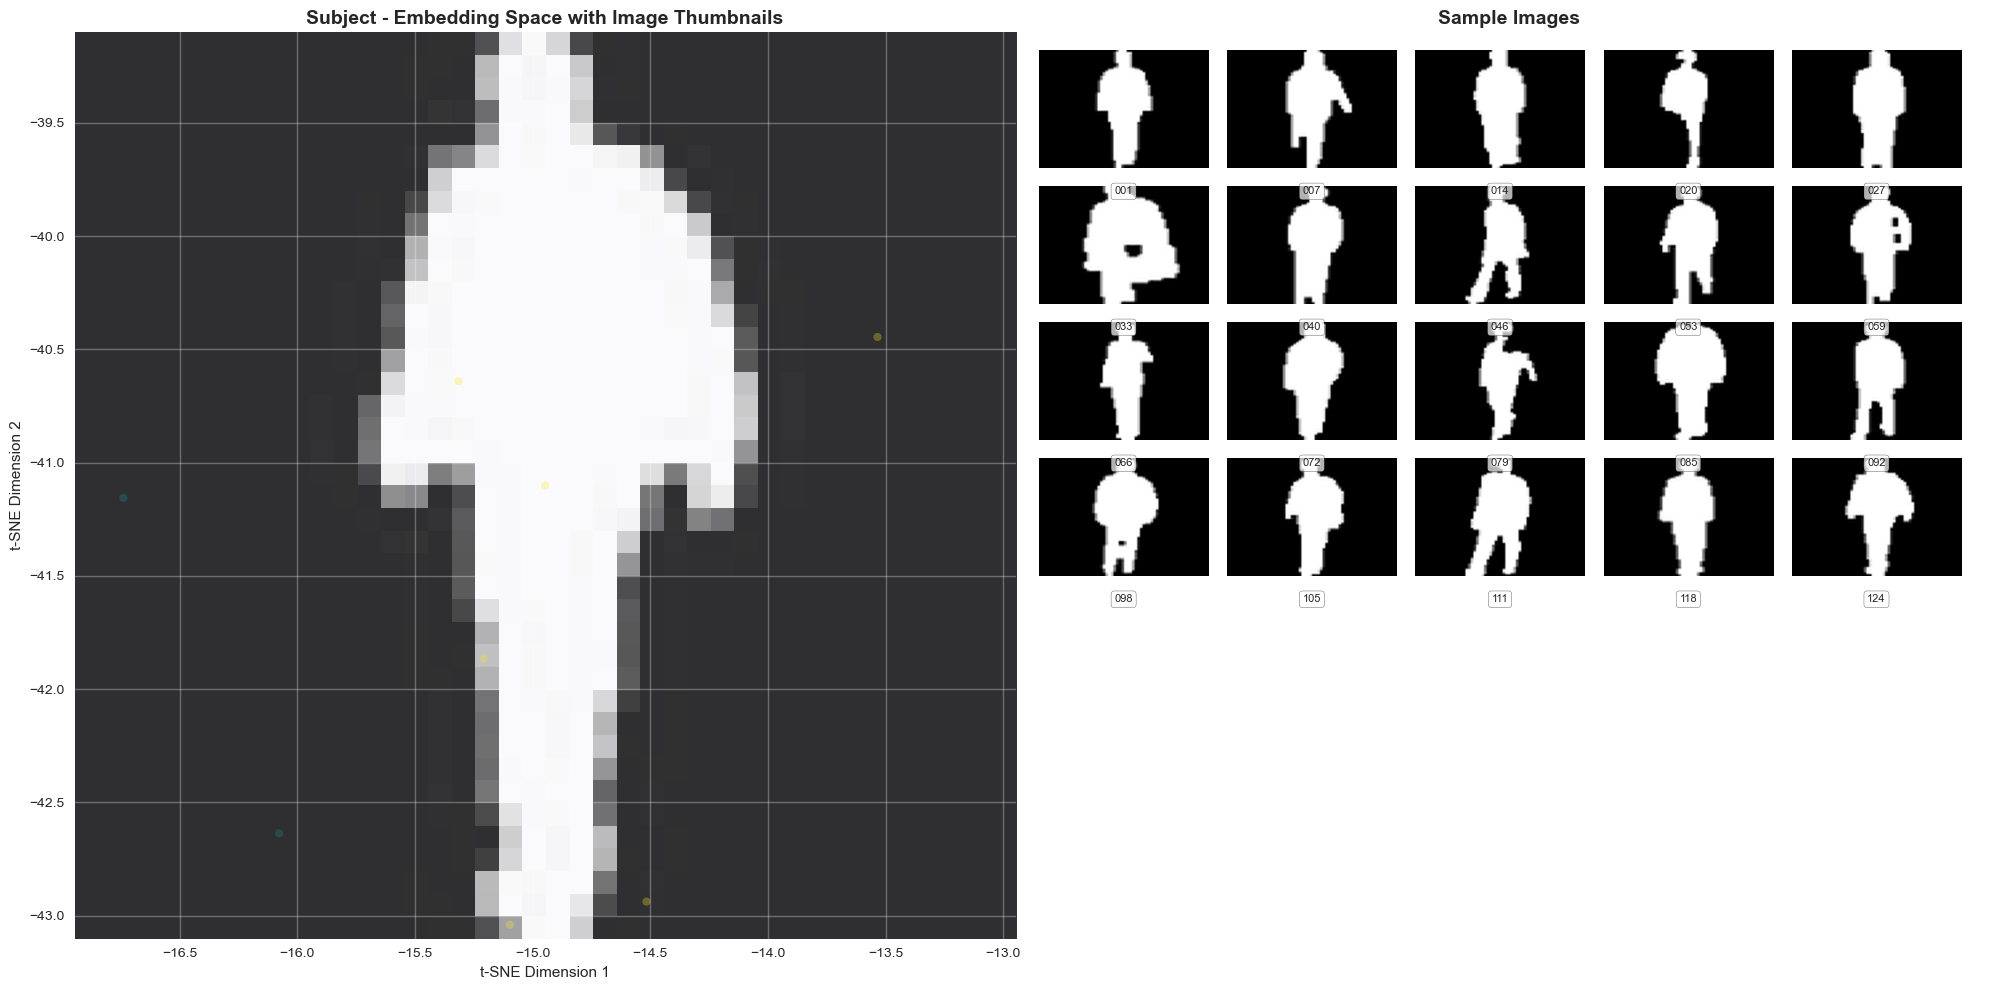

In [60]:
def plot_images_with_embeddings(image_paths, embeddings_2d, labels, title, n_samples=20):
    """
    Plot images alongside their positions in embedding space.
    """
    # Sample indices
    n_samples = min(n_samples, len(image_paths))
    indices = np.linspace(0, len(image_paths)-1, n_samples, dtype=int)
    
    fig = plt.figure(figsize=(20, 10))
    
    # Left: t-SNE plot with image thumbnails
    ax1 = plt.subplot(1, 2, 1)
    scatter = ax1.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                         c=range(len(embeddings_2d)), cmap='viridis', 
                         alpha=0.3, s=30)
    
    # Add image thumbnails at embedding positions
    for idx in indices:
        img_path = image_paths[idx]
        img = Image.open(img_path).convert('L')
        img.thumbnail((40, 40), Image.LANCZOS)
        
        # Position thumbnail at embedding location
        x, y = embeddings_2d[idx]
        ax1.imshow(img, extent=[x-2, x+2, y-2, y+2], 
                  aspect='auto', alpha=0.8, cmap='gray')
    
    ax1.set_title(f'{title} - Embedding Space with Image Thumbnails', 
                 fontsize=14, fontweight='bold')
    ax1.set_xlabel('t-SNE Dimension 1')
    ax1.set_ylabel('t-SNE Dimension 2')
    ax1.grid(True, alpha=0.3)
    
    # Right: Grid of sample images
    ax2 = plt.subplot(1, 2, 2)
    ax2.axis('off')
    
    cols = 5
    rows = (n_samples + cols - 1) // cols
    
    for i, idx in enumerate(indices):
        row = i // cols
        col = i % cols
        
        img_path = image_paths[idx]
        img = Image.open(img_path).convert('L')
        img = img.resize((64, 128), Image.LANCZOS)
        
        # Position in grid
        x_start = col * 0.2
        y_start = 1 - (row + 1) * 0.15
        
        ax2.imshow(img, extent=[x_start, x_start+0.18, y_start, y_start+0.13], 
                  aspect='auto', cmap='gray')
        
        # Add label
        label = labels[idx]
        ax2.text(x_start + 0.09, y_start - 0.02, str(label), 
                ha='center', va='top', fontsize=8, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.set_title('Sample Images', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Plot by subject
print("Displaying images with embeddings (by subject)...")
plot_images_with_embeddings(
    samples['paths'], 
    embeddings_2d, 
    samples['subjects'],
    'Subject',
    n_samples=20
)


## 7. Quantitative Analysis: Inter vs Intra Category Distances


In [ ]:
def compute_inter_intra_distances(embeddings, labels, category_name):
    """
    Compute inter-category and intra-category distances.
    Returns mean distances for analysis.
    """
    unique_labels = sorted(set(labels))
    
    intra_distances = []
    inter_distances = []
    
    for label in unique_labels:
        mask = np.array(labels) == label
        category_embeddings = embeddings[mask]
        
        if len(category_embeddings) > 1:
            # Intra-category distances
            distances = euclidean_distances(category_embeddings)
            triu_indices = np.triu_indices(len(distances), k=1)
            intra_distances.extend(distances[triu_indices].tolist())
        
        # Inter-category distances (to other categories)
        other_mask = ~mask
        if other_mask.sum() > 0:
            other_embeddings = embeddings[other_mask]
            inter_dists = euclidean_distances(category_embeddings, other_embeddings)
            inter_distances.extend(inter_dists.flatten().tolist())
    
    return {
        'intra_mean': np.mean(intra_distances) if intra_distances else 0,
        'intra_std': np.std(intra_distances) if intra_distances else 0,
        'inter_mean': np.mean(inter_distances) if inter_distances else 0,
        'inter_std': np.std(inter_distances) if inter_distances else 0,
        'separation_ratio': np.mean(inter_distances) / np.mean(intra_distances) if intra_distances and np.mean(intra_distances) > 0 else 0
    }

# Analyze distances
print("Computing inter vs intra category distances...\n")

subject_distances = compute_inter_intra_distances(embeddings, samples['subjects'], 'Subject')
print("📊 Subject Distances:")
print(f"   Intra-subject (same person): {subject_distances['intra_mean']:.4f} ± {subject_distances['intra_std']:.4f}")
print(f"   Inter-subject (different people): {subject_distances['inter_mean']:.4f} ± {subject_distances['inter_std']:.4f}")
print(f"   Separation ratio (inter/intra): {subject_distances['separation_ratio']:.2f}x")

sequence_distances = compute_inter_intra_distances(embeddings, samples['sequences'], 'Sequence')
print("\n📊 Sequence Distances:")
print(f"   Intra-sequence: {sequence_distances['intra_mean']:.4f} ± {sequence_distances['intra_std']:.4f}")
print(f"   Inter-sequence: {sequence_distances['inter_mean']:.4f} ± {sequence_distances['inter_std']:.4f}")
print(f"   Separation ratio: {sequence_distances['separation_ratio']:.2f}x")

view_distances = compute_inter_intra_distances(embeddings, samples['views'], 'View')
print("\n📊 View Distances:")
print(f"   Intra-view: {view_distances['intra_mean']:.4f} ± {view_distances['intra_std']:.4f}")
print(f"   Inter-view: {view_distances['inter_mean']:.4f} ± {view_distances['inter_std']:.4f}")
print(f"   Separation ratio: {view_distances['separation_ratio']:.2f}x")


Computing inter vs intra category distances...


VAE Analysis

📊 Subject Distances:
   Intra-subject (same person): 1.2176 ± 0.5083
   Inter-subject (different people): 1.3840 ± 0.4786
   Separation ratio (inter/intra): 1.14x

📊 Sequence Distances:
   Intra-sequence: 1.3586 ± 0.4853
   Inter-sequence: 1.3948 ± 0.4754
   Separation ratio: 1.03x

📊 View Distances:
   Intra-view: 1.3577 ± 0.4855
   Inter-view: 1.3952 ± 0.4753
   Separation ratio: 1.03x

Contrastive VAE Analysis

📊 Subject Distances:
   Intra-subject (same person): 1.4592 ± 0.6264
   Inter-subject (different people): 1.6877 ± 0.5779
   Separation ratio (inter/intra): 1.16x

📊 Sequence Distances:
   Intra-sequence: 1.6245 ± 0.5833
   Inter-sequence: 1.7167 ± 0.5738
   Separation ratio: 1.06x

📊 View Distances:
   Intra-view: 1.6629 ± 0.5902
   Inter-view: 1.6975 ± 0.5725
   Separation ratio: 1.02x

Direct Comparison: VAE vs Contrastive VAE

Subject Separation Ratio:
   VAE: 1.14x
   Contrastive VAE: 1.16x
   Improvement: +1

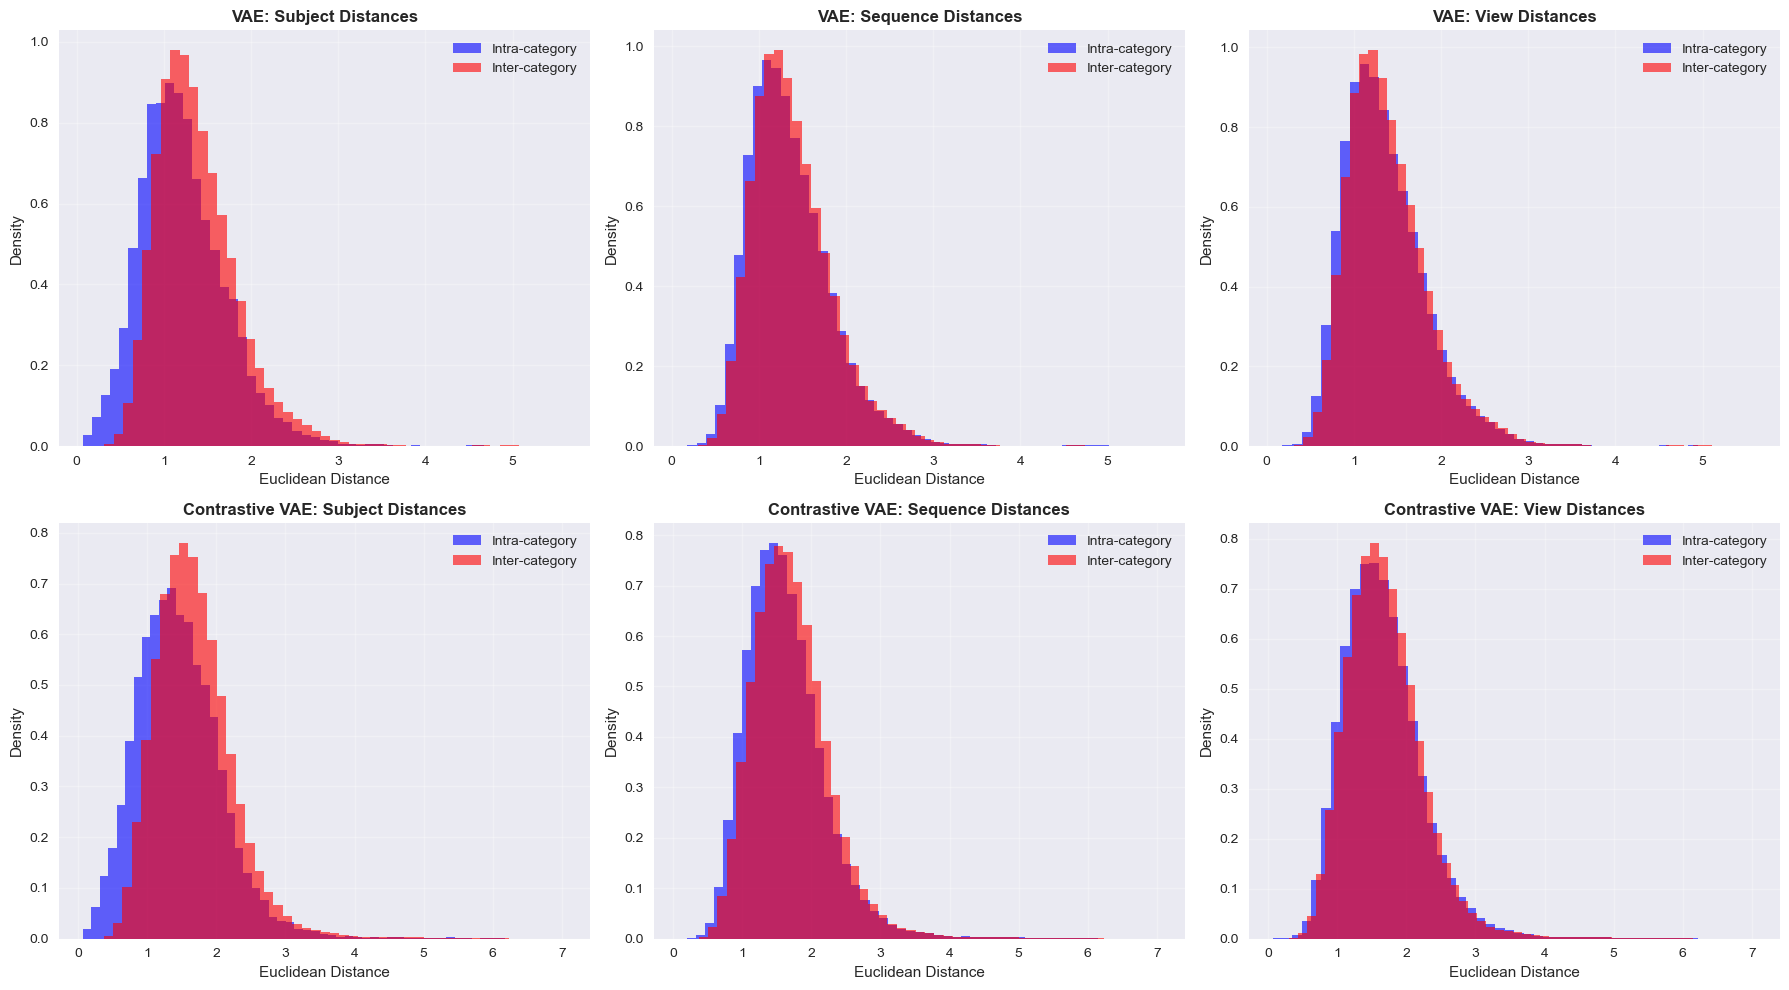

In [62]:
# Visualize distance distributions - Compare VAE vs Contrastive VAE
if 'vae' in embeddings_dict and 'contrastive' in embeddings_dict:
    # Compare both models side by side
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    def plot_distance_comparison(embeddings, labels, ax, title):
        """Plot inter vs intra distance distributions."""
        unique_labels = sorted(set(labels))
        
        intra_dists = []
        inter_dists = []
        
        for label in unique_labels:
            mask = np.array(labels) == label
            cat_embs = embeddings[mask]
            
            if len(cat_embs) > 1:
                dists = euclidean_distances(cat_embs)
                triu = np.triu_indices(len(dists), k=1)
                intra_dists.extend(dists[triu].tolist())
            
            other_mask = ~mask
            if other_mask.sum() > 0:
                other_embs = embeddings[other_mask]
                inter_dists.extend(euclidean_distances(cat_embs, other_embs).flatten().tolist())
        
        ax.hist(intra_dists, bins=50, alpha=0.6, label='Intra-category', color='blue', density=True)
        ax.hist(inter_dists, bins=50, alpha=0.6, label='Inter-category', color='red', density=True)
        ax.set_xlabel('Euclidean Distance')
        ax.set_ylabel('Density')
        ax.set_title(title, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # VAE row
    plot_distance_comparison(embeddings_dict['vae'], samples['subjects'], axes[0, 0], 'VAE: Subject Distances')
    plot_distance_comparison(embeddings_dict['vae'], samples['sequences'], axes[0, 1], 'VAE: Sequence Distances')
    plot_distance_comparison(embeddings_dict['vae'], samples['views'], axes[0, 2], 'VAE: View Distances')
    
    # Contrastive VAE row
    plot_distance_comparison(embeddings_dict['contrastive'], samples['subjects'], axes[1, 0], 'Contrastive VAE: Subject Distances')
    plot_distance_comparison(embeddings_dict['contrastive'], samples['sequences'], axes[1, 1], 'Contrastive VAE: Sequence Distances')
    plot_distance_comparison(embeddings_dict['contrastive'], samples['views'], axes[1, 2], 'Contrastive VAE: View Distances')
    
    plt.tight_layout()
    plt.show()
else:
    # Fallback to single model visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    def plot_distance_comparison(embeddings, labels, ax, title):
        """Plot inter vs intra distance distributions."""
        unique_labels = sorted(set(labels))
        
        intra_dists = []
        inter_dists = []
        
        for label in unique_labels:
            mask = np.array(labels) == label
            cat_embs = embeddings[mask]
            
            if len(cat_embs) > 1:
                dists = euclidean_distances(cat_embs)
                triu = np.triu_indices(len(dists), k=1)
                intra_dists.extend(dists[triu].tolist())
            
            other_mask = ~mask
            if other_mask.sum() > 0:
                other_embs = embeddings[other_mask]
                inter_dists.extend(euclidean_distances(cat_embs, other_embs).flatten().tolist())
        
        ax.hist(intra_dists, bins=50, alpha=0.6, label='Intra-category', color='blue', density=True)
        ax.hist(inter_dists, bins=50, alpha=0.6, label='Inter-category', color='red', density=True)
        ax.set_xlabel('Euclidean Distance')
        ax.set_ylabel('Density')
        ax.set_title(title, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plot_distance_comparison(embeddings, samples['subjects'], axes[0], 'Subject Distances')
    plot_distance_comparison(embeddings, samples['sequences'], axes[1], 'Sequence Distances')
    plot_distance_comparison(embeddings, samples['views'], axes[2], 'View Distances')
    
    plt.tight_layout()
    plt.show()


## 8. Compare Different Models (Autoencoder vs VAE)


Comparing VAE vs Contrastive VAE embeddings...


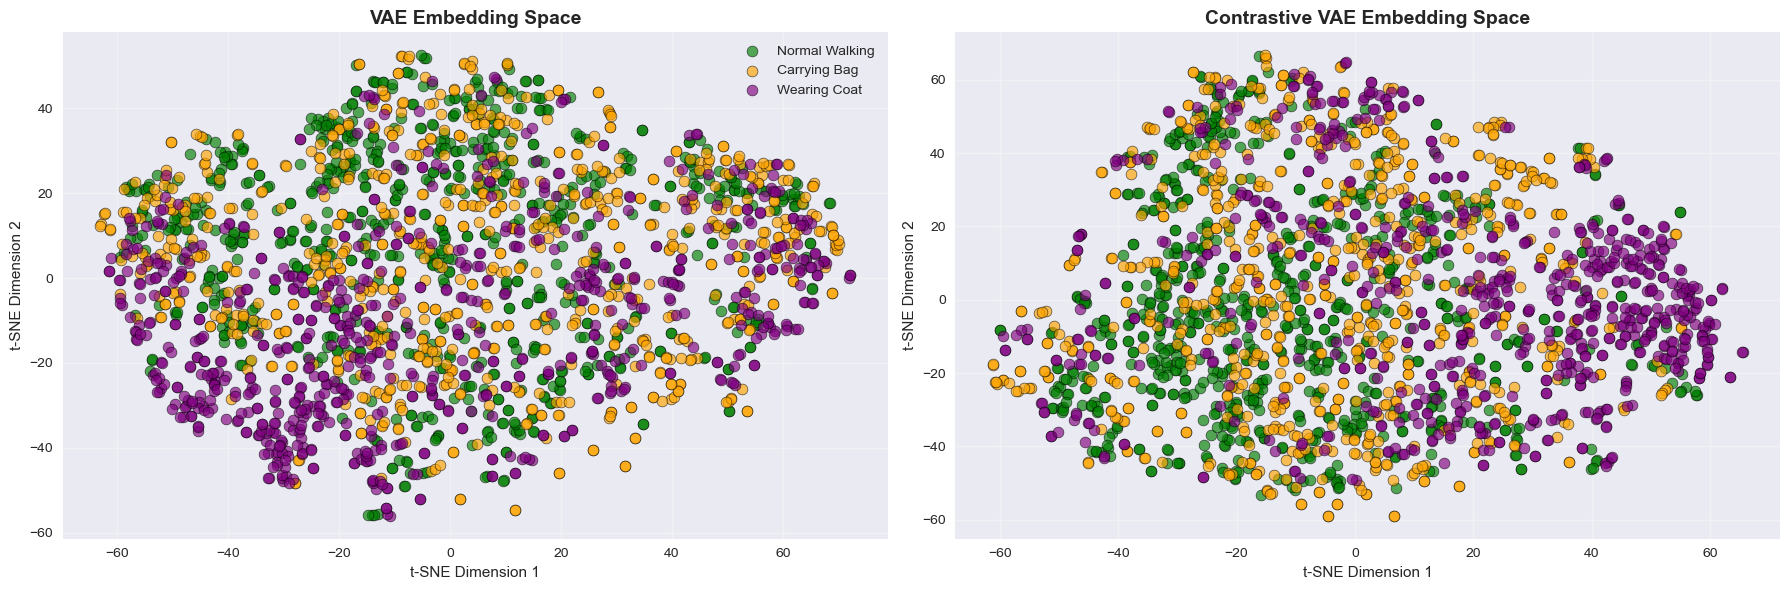


📊 Model Comparison:
   Subject separation - VAE: 1.14x | Contrastive VAE: 1.16x
   Sequence-type separation - VAE: 1.03x | Contrastive VAE: 1.06x

📈 Improvement:
   Subject separation: +1.8%
   Sequence-type separation: +2.9%

📌 VAE modality stats:
   Normal Walking: 744 samples | mean norm=3.0279
   Carrying Bag: 744 samples | mean norm=2.9938
   Wearing Coat: 744 samples | mean norm=2.8417
      Mean distance Normal Walking ↔ Carrying Bag: 0.1654
      Mean distance Normal Walking ↔ Wearing Coat: 0.3907
      Mean distance Carrying Bag ↔ Wearing Coat: 0.3150

📌 Contrastive VAE modality stats:
   Normal Walking: 744 samples | mean norm=3.5930
   Carrying Bag: 744 samples | mean norm=3.5279
   Wearing Coat: 744 samples | mean norm=3.3960
      Mean distance Normal Walking ↔ Carrying Bag: 0.2506
      Mean distance Normal Walking ↔ Wearing Coat: 0.7288
      Mean distance Carrying Bag ↔ Wearing Coat: 0.5559


In [63]:
# Compare embeddings from VAE and Contrastive VAE
if 'vae' in embeddings_dict and 'contrastive' in embeddings_dict:
    print("Comparing VAE vs Contrastive VAE embeddings...")
    vae_embeddings = embeddings_dict['vae']
    contrastive_embeddings = embeddings_dict['contrastive']

    def run_tsne(embeddings):
        pca = PCA(n_components=50)
        reduced = pca.fit_transform(embeddings)
        return TSNE(n_components=2, random_state=42, perplexity=min(30, len(reduced)-1)).fit_transform(reduced[:, :50])

    vae_tsne = run_tsne(vae_embeddings)
    contrastive_tsne = run_tsne(contrastive_embeddings)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    for ax, tsne_coords, title in zip(
        axes,
        [vae_tsne, contrastive_tsne],
        ['VAE Embedding Space', 'Contrastive VAE Embedding Space']
    ):
        for seq_type in ['nm', 'bg', 'cl']:
            mask = np.array(sequence_types) == seq_type
            if mask.sum() > 0:
                ax.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
                           c=sequence_type_colors[seq_type],
                           label=sequence_type_labels[seq_type],
                           alpha=0.65, s=60, edgecolors='black', linewidths=0.5)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel('t-SNE Dimension 1')
        ax.set_ylabel('t-SNE Dimension 2')
        ax.grid(True, alpha=0.3)

    axes[0].legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    # Compare separation ratios for subjects and sequence types
    vae_subj_dist = compute_inter_intra_distances(vae_embeddings, samples['subjects'], 'Subject')
    contrastive_subj_dist = compute_inter_intra_distances(contrastive_embeddings, samples['subjects'], 'Subject')

    vae_seq_dist = compute_inter_intra_distances(vae_embeddings, sequence_types, 'Sequence Type')
    contrastive_seq_dist = compute_inter_intra_distances(contrastive_embeddings, sequence_types, 'Sequence Type')

    print("\n📊 Model Comparison:")
    print(f"   Subject separation - VAE: {vae_subj_dist['separation_ratio']:.2f}x | Contrastive VAE: {contrastive_subj_dist['separation_ratio']:.2f}x")
    print(f"   Sequence-type separation - VAE: {vae_seq_dist['separation_ratio']:.2f}x | Contrastive VAE: {contrastive_seq_dist['separation_ratio']:.2f}x")
    
    # Improvement metrics
    subj_improvement = ((contrastive_subj_dist['separation_ratio'] - vae_subj_dist['separation_ratio']) / vae_subj_dist['separation_ratio']) * 100
    seq_improvement = ((contrastive_seq_dist['separation_ratio'] - vae_seq_dist['separation_ratio']) / vae_seq_dist['separation_ratio']) * 100
    print(f"\n📈 Improvement:")
    print(f"   Subject separation: {subj_improvement:+.1f}%")
    print(f"   Sequence-type separation: {seq_improvement:+.1f}%")

    # Detailed modality statistics per model
    for model_name, model_embeddings in [('VAE', vae_embeddings), ('Contrastive VAE', contrastive_embeddings)]:
        print(f"\n📌 {model_name} modality stats:")
        modality_means = {}
        for seq_type in ['nm', 'bg', 'cl']:
            mask = np.array(sequence_types) == seq_type
            if mask.sum() == 0:
                continue
            seq_embs = model_embeddings[mask]
            modality_means[seq_type] = seq_embs.mean(axis=0)
            intra = compute_inter_intra_distances(seq_embs, np.array(sequence_types)[mask], seq_type)
            print(f"   {sequence_type_labels[seq_type]}: {mask.sum()} samples | mean norm={np.linalg.norm(modality_means[seq_type]):.4f}")

        # Pairwise modality distances
        pairs = [('nm','bg'), ('nm','cl'), ('bg','cl')]
        for a, b in pairs:
            if a in modality_means and b in modality_means:
                dist = np.linalg.norm(modality_means[a] - modality_means[b])
                print(f"      Mean distance {sequence_type_labels[a]} ↔ {sequence_type_labels[b]}: {dist:.4f}")
else:
    print("⚠️  Both VAE and Contrastive VAE models not available for comparison")
    if 'vae' in embeddings_dict:
        print("   ✅ VAE available")
    if 'contrastive' in embeddings_dict:
        print("   ✅ Contrastive VAE available")


## 9. Subject Embedding Comparison (VAE vs Contrastive VAE)


Plotting subjects: ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010']


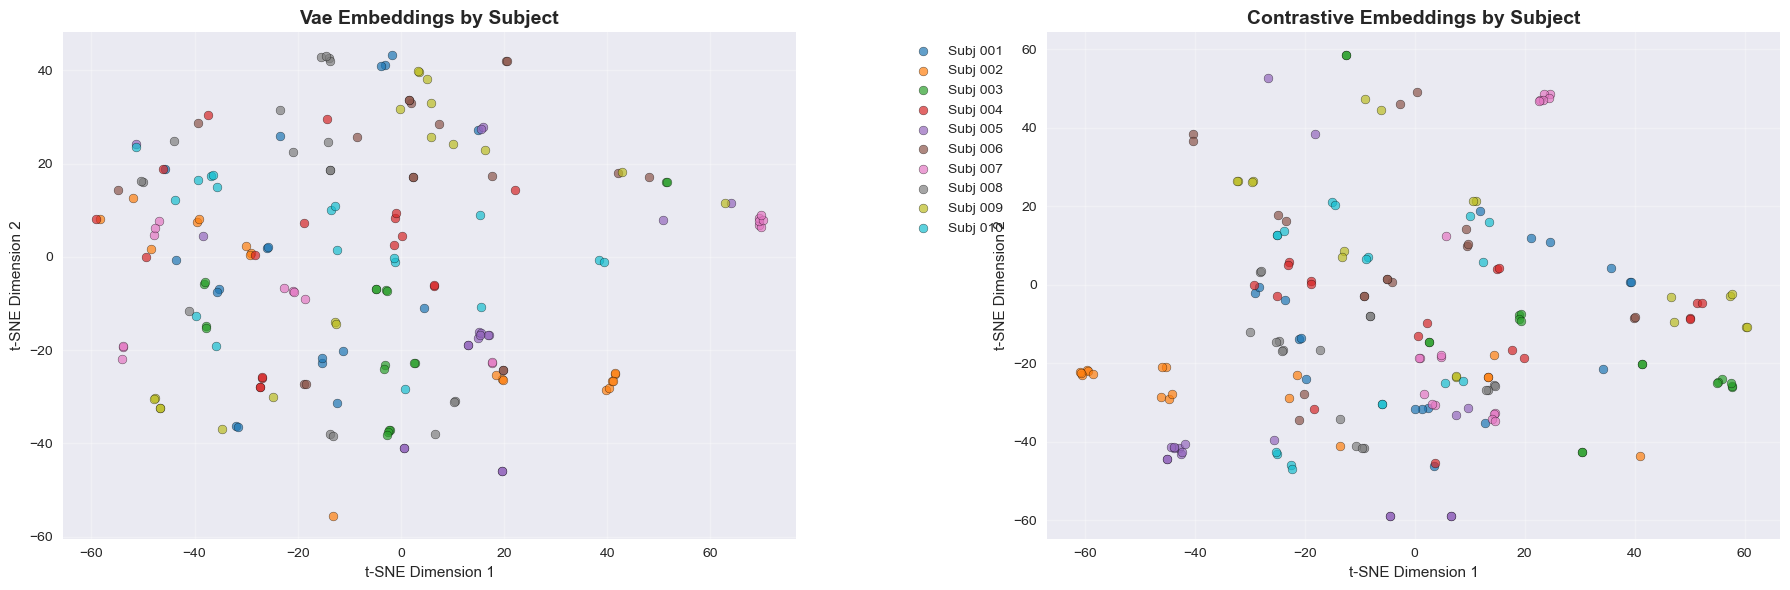

In [64]:
# Visualize subject clusters for each embedding space
subject_values = np.array(samples['subjects'])
unique_subjects = sorted(set(subject_values))
max_subjects = min(10, len(unique_subjects))
selected_subjects = unique_subjects[:max_subjects]
subject_colors = plt.cm.tab10(np.linspace(0, 1, max_subjects))

print(f"Plotting subjects: {selected_subjects}")

def run_tsne_subjects(embeddings):
    pca = PCA(n_components=50)
    reduced = pca.fit_transform(embeddings)
    return TSNE(n_components=2, random_state=42, perplexity=min(30, len(reduced)-1)).fit_transform(reduced[:, :50])

fig, axes = plt.subplots(1, len(embeddings_dict), figsize=(9 * len(embeddings_dict), 6), squeeze=False)
axes = axes[0]

for ax, (model_name, model_embeddings) in zip(axes, embeddings_dict.items()):
    coords = run_tsne_subjects(model_embeddings)
    for color, subj in zip(subject_colors, selected_subjects):
        mask = subject_values == subj
        ax.scatter(coords[mask, 0], coords[mask, 1], 
                   c=[color], label=f'Subj {subj}', alpha=0.7, s=40, edgecolors='black', linewidths=0.3)
    ax.set_title(f'{model_name.title()} Embeddings by Subject', fontsize=14, fontweight='bold')
    ax.set_xlabel('t-SNE Dimension 1')
    ax.set_ylabel('t-SNE Dimension 2')
    ax.grid(True, alpha=0.3)

axes[0].legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.show()


## 10. Classify Subjects from Embeddings


In [65]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

subject_labels = np.array(samples['subjects'])
subject_encoder = LabelEncoder()
y_subject = subject_encoder.fit_transform(subject_labels)
subject_names = subject_encoder.classes_
TOP_K_VALUES = [1, 3, 5]


def compute_topk_accuracy(probs, y_true, k):
    topk_preds = np.argsort(probs, axis=1)[:, ::-1][:, :k]
    hits = np.any(topk_preds == y_true[:, None], axis=1)
    return hits.mean()


for model_name, model_embeddings in embeddings_dict.items():
    print(f"\n🧠 Subject classification (top-k) using {model_name} embeddings")

    X_train, X_test, y_train, y_test = train_test_split(
        model_embeddings, y_subject, test_size=0.2, random_state=42, stratify=y_subject
    )

    clf = LogisticRegression(max_iter=2000, multi_class='multinomial')
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    probs = clf.predict_proba(X_test)

    for k in TOP_K_VALUES:
        if k <= probs.shape[1]:
            topk_acc = compute_topk_accuracy(probs, y_test, k)
            print(f"   Top-{k} accuracy: {topk_acc:.3f}")

    print("   Classification report (Top-1):")
    print(classification_report(y_test, y_pred, target_names=subject_names))

    cm = confusion_matrix(y_test, y_pred)
    print("   Confusion matrix (rows=true, cols=pred):")
    print(cm)

    # Random baseline for comparison
    dummy = DummyClassifier(strategy='uniform', random_state=42)
    dummy.fit(X_train, y_train)
    dummy_probs = dummy.predict_proba(X_test)

    for k in TOP_K_VALUES:
        if k <= dummy_probs.shape[1]:
            topk_acc = compute_topk_accuracy(dummy_probs, y_test, k)
            print(f"   Random baseline Top-{k}: {topk_acc:.3f}")

    dummy_pred = dummy.predict(X_test)
    print("   Random baseline report:")
    print(classification_report(y_test, dummy_pred, target_names=subject_names))




🧠 Subject classification (top-k) using vae embeddings
   Top-1 accuracy: 0.161
   Top-3 accuracy: 0.286
   Top-5 accuracy: 0.358
   Classification report (Top-1):
              precision    recall  f1-score   support

         001       0.00      0.00      0.00         3
         002       0.40      0.50      0.44         4
         003       0.20      0.50      0.29         4
         004       0.00      0.00      0.00         4
         005       0.25      0.67      0.36         3
         006       0.00      0.00      0.00         4
         007       0.00      0.00      0.00         4
         008       0.50      0.25      0.33         4
         009       0.00      0.00      0.00         4
         010       0.00      0.00      0.00         3
         011       0.20      0.67      0.31         3
         012       0.33      0.33      0.33         3
         013       0.00      0.00      0.00         3
         014       0.00      0.00      0.00         4
         015       1.00  

In [ ]:
## 11. Classify Sequence Modalities from Embeddings (Top-k + Baseline)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier

# Encode sequence types as integers for classification
seq_type_values = np.array(sequence_types)
unique_types = sorted(set(seq_type_values))
type_to_idx = {seq: idx for idx, seq in enumerate(unique_types)}
y = np.array([type_to_idx[seq] for seq in seq_type_values])
TOP_K_VALUES = [1, 2, 3]


def compute_topk_accuracy(probs, y_true, k):
    topk_preds = np.argsort(probs, axis=1)[:, ::-1][:, :k]
    hits = np.any(topk_preds == y_true[:, None], axis=1)
    return hits.mean()


for model_name, model_embeddings in embeddings_dict.items():
    print(f"\n🔍 Modality classification using {model_name} embeddings")

    X_train, X_test, y_train, y_test = train_test_split(
        model_embeddings, y, test_size=0.2, random_state=42, stratify=y
    )

    clf = LogisticRegression(max_iter=2000, multi_class='multinomial')
    clf.fit(X_train, y_train)

    probs = clf.predict_proba(X_test)
    y_pred = np.argmax(probs, axis=1)

    for k in TOP_K_VALUES:
        topk_acc = compute_topk_accuracy(probs, y_test, k)
        print(f"   Top-{k} accuracy: {topk_acc:.3f}")

    print("   Classification report (Top-1):")
    print(classification_report(y_test, y_pred, target_names=[sequence_type_labels[t] for t in unique_types]))

    cm = confusion_matrix(y_test, y_pred)
    print("   Confusion matrix (rows=true, cols=pred):")
    print(cm)

    # Random baseline
    dummy = DummyClassifier(strategy='uniform', random_state=42)
    dummy.fit(X_train, y_train)
    dummy_probs = dummy.predict_proba(X_test)
    for k in TOP_K_VALUES:
        topk_acc = compute_topk_accuracy(dummy_probs, y_test, k)
        print(f"   Random baseline Top-{k}: {topk_acc:.3f}")

    dummy_pred = dummy.predict(X_test)
    print("   Random baseline report:")
    print(classification_report(y_test, dummy_pred, target_names=[sequence_type_labels[t] for t in unique_types]))




🔍 Modality classification using vae embeddings
   Top-1 accuracy: 0.609
   Top-2 accuracy: 0.850
   Top-3 accuracy: 1.000
   Classification report (Top-1):
                precision    recall  f1-score   support

  Carrying Bag       0.60      0.48      0.53       149
  Wearing Coat       0.69      0.71      0.70       149
Normal Walking       0.55      0.64      0.59       149

      accuracy                           0.61       447
     macro avg       0.61      0.61      0.61       447
  weighted avg       0.61      0.61      0.61       447

   Confusion matrix (rows=true, cols=pred):
[[ 71  22  56]
 [ 20 106  23]
 [ 28  26  95]]
   Random baseline Top-1: 0.333
   Random baseline Top-2: 0.667
   Random baseline Top-3: 1.000
   Random baseline report:
                precision    recall  f1-score   support

  Carrying Bag       0.31      0.30      0.30       149
  Wearing Coat       0.33      0.32      0.32       149
Normal Walking       0.35      0.36      0.36       149

      acc

## 13. Advanced Classifiers: SVM and Neural Network

Compare SVM and small neural network classifiers with nearest neighbor baseline.

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Small neural network classifier
class EmbeddingClassifier(nn.Module):
    """Small neural network for embedding classification."""
    
    def __init__(self, input_dim, num_classes, hidden_dims=[256, 128], dropout=0.3):
        super(EmbeddingClassifier, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        
        # Output layer
        layers.append(nn.Linear(prev_dim, num_classes))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

def train_neural_network(X_train, y_train, X_val, y_val, num_classes, 
                        epochs=100, batch_size=64, lr=0.001, patience=10):
    """Train a small neural network classifier."""
    input_dim = X_train.shape[1]
    
    # Convert to tensors
    X_train_t = torch.FloatTensor(X_train).to(device)
    y_train_t = torch.LongTensor(y_train).to(device)
    X_val_t = torch.FloatTensor(X_val).to(device)
    y_val_t = torch.LongTensor(y_val).to(device)
    
    # Create model
    model = EmbeddingClassifier(input_dim, num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    # Data loaders
    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    best_val_acc = 0
    best_model_state = None
    patience_counter = 0
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_t)
            val_pred = val_outputs.argmax(dim=1)
            val_acc = accuracy_score(y_val, val_pred.cpu().numpy())
        
        scheduler.step(train_loss / len(train_loader))
        
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return model, best_val_acc

print("=" * 80)
print("ADVANCED CLASSIFIERS: SVM & NEURAL NETWORK")
print("=" * 80)

# Split data (same split as before for fair comparison)
test_size = 0.2
val_size = 0.1  # 10% of training data for validation
random_state = 42

all_labels = np.array(samples['subjects'])
num_classes = len(np.unique(all_labels))

# Encode labels as integers
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
all_labels_encoded = label_encoder.fit_transform(all_labels)

results_summary = {}

# Test each model's embeddings
for model_name, model_embeddings in embeddings_dict.items():
    print(f"\n{'='*80}")
    print(f"Model: {model_name.upper()}")
    print(f"{'='*80}")
    
    # First split: train+val vs test
    X_temp, X_test, y_temp, y_test = train_test_split(
        model_embeddings,
        all_labels_encoded,
        test_size=test_size,
        random_state=random_state,
        stratify=all_labels_encoded
    )
    
    # Second split: train vs val
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp,
        y_temp,
        test_size=val_size / (1 - test_size),  # Adjust for previous split
        random_state=random_state,
        stratify=y_temp
    )
    
    print(f"Training samples: {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")
    print(f"Test samples: {len(X_test)}")
    print(f"Number of classes: {num_classes}")
    
    results_summary[model_name] = {}
    
    # 1. Nearest Neighbor (baseline)
    print(f"\n--- 1. Nearest Neighbor (k=1) ---")
    nn_model = NearestNeighbors(n_neighbors=1, metric='euclidean')
    nn_model.fit(X_train)
    distances, indices = nn_model.kneighbors(X_test)
    nn_pred = y_train[indices[:, 0]]
    nn_acc = accuracy_score(y_test, nn_pred)
    print(f"Accuracy: {nn_acc:.4f} ({nn_acc*100:.2f}%)")
    results_summary[model_name]['k-NN'] = nn_acc
    
    # 2. SVM with RBF kernel
    print(f"\n--- 2. SVM (RBF Kernel) ---")
    # Scale features for SVM
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train SVM (use smaller C for faster training with many classes)
    svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=random_state, 
                    decision_function_shape='ovr', verbose=False)
    print("Training SVM... (this may take a minute)")
    svm_model.fit(X_train_scaled, y_train)
    svm_pred = svm_model.predict(X_test_scaled)
    svm_acc = accuracy_score(y_test, svm_pred)
    print(f"Accuracy: {svm_acc:.4f} ({svm_acc*100:.2f}%)")
    results_summary[model_name]['SVM'] = svm_acc
    
    # 3. Small Neural Network
    print(f"\n--- 3. Neural Network ---")
    print("Training neural network...")
    nn_classifier, val_acc = train_neural_network(
        X_train, y_train, X_val, y_val, num_classes,
        epochs=100, batch_size=64, lr=0.001, patience=10
    )
    
    # Evaluate on test set
    nn_classifier.eval()
    with torch.no_grad():
        X_test_t = torch.FloatTensor(X_test).to(device)
        nn_outputs = nn_classifier(X_test_t)
        nn_pred_nn = nn_outputs.argmax(dim=1).cpu().numpy()
    
    nn_nn_acc = accuracy_score(y_test, nn_pred_nn)
    print(f"Validation accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
    print(f"Test accuracy: {nn_nn_acc:.4f} ({nn_nn_acc*100:.2f}%)")
    results_summary[model_name]['Neural Network'] = nn_nn_acc
    
    # Show detailed classification report for best method
    print(f"\n--- Best Method: {max(results_summary[model_name], key=results_summary[model_name].get)} ---")
    best_method = max(results_summary[model_name], key=results_summary[model_name].get)
    if best_method == 'k-NN':
        best_pred = nn_pred
    elif best_method == 'SVM':
        best_pred = svm_pred
    else:
        best_pred = nn_pred_nn
    
    subject_names = label_encoder.classes_
    print(classification_report(y_test, best_pred, target_names=subject_names, zero_division=0))

# Final comparison
print(f"\n{'='*80}")
print("FINAL COMPARISON: All Models & All Classifiers")
print(f"{'='*80}\n")

# Create comparison table
print(f"{'Model':<20} {'k-NN':<12} {'SVM':<12} {'Neural Net':<12} {'Best':<12}")
print("-" * 80)

for model_name in embeddings_dict.keys():
    knn_acc = results_summary[model_name]['k-NN']
    svm_acc = results_summary[model_name]['SVM']
    nn_acc = results_summary[model_name]['Neural Network']
    best_acc = max(knn_acc, svm_acc, nn_acc)
    best_method = max(results_summary[model_name], key=results_summary[model_name].get)
    
    print(f"{model_name:<20} {knn_acc*100:>6.2f}%   {svm_acc*100:>6.2f}%   {nn_acc*100:>6.2f}%   {best_method:<12} ({best_acc*100:.2f}%)")

# Find overall best
overall_best = None
overall_best_acc = 0
for model_name, methods in results_summary.items():
    for method, acc in methods.items():
        if acc > overall_best_acc:
            overall_best_acc = acc
            overall_best = (model_name, method)

if overall_best:
    print(f"\n🏆 Overall Best: {overall_best[0]} + {overall_best[1]} = {overall_best_acc:.4f} ({overall_best_acc*100:.2f}%)")
    
    # Calculate improvement over baseline
    baseline_acc = results_summary[overall_best[0]]['k-NN']
    improvement = ((overall_best_acc - baseline_acc) / baseline_acc) * 100
    print(f"   Improvement over k-NN baseline: +{improvement:.1f}%")


ADVANCED CLASSIFIERS: SVM & NEURAL NETWORK

Model: VAE
Training samples: 1561
Validation samples: 224
Test samples: 447
Number of classes: 124

--- 1. Nearest Neighbor (k=1) ---
Accuracy: 0.4564 (45.64%)

--- 2. SVM (RBF Kernel) ---
Training SVM... (this may take a minute)
Accuracy: 0.2953 (29.53%)

--- 3. Neural Network ---
Training neural network...
Validation accuracy: 0.5045 (50.45%)
Test accuracy: 0.4676 (46.76%)

--- Best Method: Neural Network ---
              precision    recall  f1-score   support

         001       0.33      0.33      0.33         3
         002       1.00      0.50      0.67         4
         003       0.67      0.50      0.57         4
         004       0.67      0.50      0.57         4
         005       0.50      0.67      0.57         3
         006       0.33      0.50      0.40         4
         007       0.38      0.75      0.50         4
         008       0.33      1.00      0.50         4
         009       0.00      0.00      0.00         4


## 12. Nearest Neighbor Classification

Classify subjects by finding the nearest embedding in the training set.

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import NearestNeighbors
import numpy as np

def nearest_neighbor_classify(train_embeddings, train_labels, test_embeddings, test_labels, k=1):
    """
    Classify test samples using nearest neighbor in embedding space.
    
    Args:
        train_embeddings: Training embeddings (N_train, embedding_dim)
        train_labels: Training labels (N_train,)
        test_embeddings: Test embeddings (N_test, embedding_dim)
        test_labels: Test labels (N_test,)
        k: Number of neighbors to consider (default: 1)
    
    Returns:
        predictions: Predicted labels (N_test,)
        accuracy: Classification accuracy
    """
    # Fit nearest neighbor model
    nn = NearestNeighbors(n_neighbors=k, metric='euclidean')
    nn.fit(train_embeddings)
    
    # Find nearest neighbors for test samples
    distances, indices = nn.kneighbors(test_embeddings)
    
    # Get predictions (for k=1, just use the nearest neighbor's label)
    if k == 1:
        predictions = train_labels[indices[:, 0]]
    else:
        # For k>1, use majority vote
        predictions = []
        for idx_list in indices:
            neighbor_labels = train_labels[idx_list]
            # Count votes
            unique_labels, counts = np.unique(neighbor_labels, return_counts=True)
            # Get label with most votes
            pred = unique_labels[np.argmax(counts)]
            predictions.append(pred)
        predictions = np.array(predictions)
    
    # Calculate accuracy
    accuracy = accuracy_score(test_labels, predictions)
    
    return predictions, accuracy

# Perform nearest neighbor classification for each model
print("=" * 80)
print("NEAREST NEIGHBOR CLASSIFICATION")
print("=" * 80)

# Split data into train/test (80/20 split)
test_size = 0.2
random_state = 42

# Get labels (subjects)
all_labels = np.array(samples['subjects'])

# Run classification for each model
for model_name, model_embeddings in embeddings_dict.items():
    print(f"\n{'='*80}")
    print(f"Model: {model_name.upper()}")
    print(f"{'='*80}")
    
    # Split embeddings and labels
    X_train, X_test, y_train, y_test = train_test_split(
        model_embeddings, 
        all_labels, 
        test_size=test_size, 
        random_state=random_state,
        stratify=all_labels  # Maintain class distribution
    )
    
    print(f"Training samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")
    print(f"Number of unique subjects: {len(np.unique(all_labels))}")
    
    # Try different k values
    for k in [1, 3, 5]:
        predictions, accuracy = nearest_neighbor_classify(
            X_train, y_train, X_test, y_test, k=k
        )
        print(f"\n  k={k} Nearest Neighbor Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    # Detailed report for k=1
    print(f"\n  Detailed Classification Report (k=1):")
    predictions_k1, _ = nearest_neighbor_classify(X_train, y_train, X_test, y_test, k=1)
    
    # Get unique subjects for report
    unique_subjects = sorted(np.unique(all_labels))
    print(classification_report(y_test, predictions_k1, target_names=unique_subjects, zero_division=0))
    
    # Show some example predictions
    print(f"\n  Example Predictions (first 10 test samples):")
    for i in range(min(10, len(X_test))):
        print(f"    Test {i+1}: True={y_test[i]}, Predicted={predictions_k1[i]}, {'✓' if y_test[i] == predictions_k1[i] else '✗'}")

print(f"\n{'='*80}")
print("COMPARISON SUMMARY")
print(f"{'='*80}")

# Compare all models side by side
comparison_results = {}
for model_name, model_embeddings in embeddings_dict.items():
    X_train, X_test, y_train, y_test = train_test_split(
        model_embeddings, 
        all_labels, 
        test_size=test_size, 
        random_state=random_state,
        stratify=all_labels
    )
    predictions, accuracy = nearest_neighbor_classify(X_train, y_train, X_test, y_test, k=1)
    comparison_results[model_name] = accuracy
    print(f"{model_name:20s}: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Find best model
if comparison_results:
    best_model = max(comparison_results, key=comparison_results.get)
    best_acc = comparison_results[best_model]
    print(f"\n🏆 Best Model: {best_model} with {best_acc:.4f} ({best_acc*100:.2f}%) accuracy")


NEAREST NEIGHBOR CLASSIFICATION

Model: VAE
Training samples: 1785
Test samples: 447
Number of unique subjects: 124

  k=1 Nearest Neighbor Accuracy: 0.5101 (51.01%)

  k=3 Nearest Neighbor Accuracy: 0.2796 (27.96%)

  k=5 Nearest Neighbor Accuracy: 0.2394 (23.94%)

  Detailed Classification Report (k=1):
              precision    recall  f1-score   support

         001       0.22      0.67      0.33         3
         002       0.80      1.00      0.89         4
         003       1.00      1.00      1.00         4
         004       0.33      0.25      0.29         4
         005       0.67      0.67      0.67         3
         006       1.00      0.25      0.40         4
         007       0.40      0.50      0.44         4
         008       1.00      0.50      0.67         4
         009       0.00      0.00      0.00         4
         010       0.14      0.33      0.20         3
         011       0.60      1.00      0.75         3
         012       1.00      0.67      0.80 

## Summary

This analysis shows:
- **Subject separation**: How well the model distinguishes between different people
- **Sequence variation**: How embeddings vary across different walking conditions (normal, carrying bag, wearing coat)
- **View invariance**: How embeddings change with different camera angles
- **Model comparison**: Differences between Autoencoder and VAE embedding spaces

**Key Insights:**
- Higher separation ratio (inter/intra) indicates better discrimination
- Clustered points in t-SNE suggest similar embeddings
- Images displayed alongside embeddings help understand what the model learns
